<a href="https://colab.research.google.com/github/shagun30107-bit/csot-ml-astronomy/blob/main/WEEK3(PART1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cpu


In [2]:
RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2" / "images"
DATA_ROOT = Path("galaxy_data")
LABELS_URL = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"


!pip install -q kaggle
# Kaggle authentication
os.environ["KAGGLE_API_TOKEN"] = "KGAT_3f3d786e5f471c9718d9cc3a6e481eb9"

# Download Galaxy Zoo 2 dataset
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images -p galaxy_raw

# Extract dataset
!unzip -q -o galaxy_raw/galaxy-zoo-2-images.zip -d {RAW_ROOT}

# !unzip -q -o {RAW_ROOT}/images_gz2.zip -d {IMAGES_DIR}

# Download Hart et al. labels
!wget -q -O {RAW_ROOT}/gz2_hart16.csv.gz {LABELS_URL}
!gunzip -f {RAW_ROOT}/gz2_hart16.csv.gz


Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [02:28<00:00, 22.2MB/s]



In [3]:
print("RAW_ROOT contents:", sorted(p.name for p in RAW_ROOT.iterdir()))
jpg_count = sum(1 for _ in IMAGES_DIR.glob("*.jpg"))
print(f"Flat JPG count in {IMAGES_DIR}: {jpg_count:,}")

mapping_head = pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv", nrows=3)

RAW_ROOT contents: ['galaxy-zoo-2-images.zip', 'gz2_filename_mapping.csv', 'gz2_hart16.csv', 'images_gz2']
Flat JPG count in galaxy_raw/images_gz2/images: 243,434


In [4]:
def high_level_label(gz2_class: str):
    """Collapse detailed GZ2 morphology codes to a few training buckets."""
    if not gz2_class or gz2_class == "A":
        return None  # artifact / ambiguous — skip
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    return None


def build_imagefolder_layout(
    images_dir,
    mapping_csv,
    labels_csv,
    out_root,
    per_class=200,
    seed=42,
):
    """Symlink a balanced subset into out_root// for ImageFolder."""
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv).rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"])

    images_dir = Path(images_dir)
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    counts = {}
    for label in sorted(df["label"].unique()):
        class_dir = out_root / label
        class_dir.mkdir(exist_ok=True)
        rows = df[df["label"] == label]
        if len(rows) > per_class:
            rows = rows.sample(n=per_class, random_state=seed)
        linked = 0
        for _, row in rows.iterrows():
            src = images_dir / f"{int(row.asset_id)}.jpg"
            dst = class_dir / f"{int(row.asset_id)}.jpg"
            if src.exists() and not dst.exists():
                os.symlink(src.resolve(), dst)
                linked += 1
        counts[label] = linked
    return counts

PER_CLASS = 200  # balanced subset — fast on Colab; increase once the pipeline works
counts = build_imagefolder_layout(
    IMAGES_DIR,
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
    DATA_ROOT,
    per_class=PER_CLASS,
)
print("Symlinked per class:", counts)
print("DATA_ROOT classes:", sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir()))

Symlinked per class: {'elliptical': 200, 'spiral': 200, 'spiral_barred': 200}
DATA_ROOT classes: ['elliptical', 'spiral', 'spiral_barred']


In [5]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

In [6]:
from torch.utils.data import DataLoader
from torch.utils.data import random_split

dataset = ImageFolder(root=DATA_ROOT, transform=transform)

train_size = int(0.7 * len(dataset))
val_size   = int(0.15 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    dataset,
    [train_size, val_size, test_size]
)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
num_classes = len(train_ds.dataset.classes)

print("Classes      :", train_ds.dataset.classes)
print("Num_Classes  :", num_classes)



Classes      : ['elliptical', 'spiral', 'spiral_barred']
Num_Classes  : 3


In [7]:
class GalaxyCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
import torch
import torch.nn as nn

class GalaxyCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()                                  # MUST be first
        # --- Feature extractor: two Conv -> ReLU -> Pool blocks ---
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),     # (B, 16, 64, 64)
            nn.ReLU(),
            nn.MaxPool2d(2),                                 # (B, 16, 32, 32)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),    # (B, 32, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(2),                                 # (B, 32, 16, 16)
        )
        # --- Classifier head ---
        self.classifier = nn.Sequential(
            nn.Flatten(),                                    # (B, 8192)
            nn.Linear(32 * 16 * 16, 128),                    # (B, 128)
            nn.ReLU(),
            nn.Linear(128, num_classes),                     # (B, num_classes) logits
        )

    def forward(self, x):                                    # x: (B, 3, 64, 64)
        x = self.features(x)                                 # (B, 32, 16, 16)
        x = self.classifier(x)                               # (B, num_classes)
        return x

In [8]:
model= GalaxyCNN(num_classes=num_classes).to(device)
print(model)

GalaxyCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


In [9]:
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)
logits=model(images)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total params: {total_params:,}")
print(logits.shape)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Total params: 1,054,179
torch.Size([32, 3])


In [10]:
import math
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss=criterion(logits, labels)
print(loss.item(),"vs ln(C)",math.log(num_classes))

1.098974585533142 vs ln(C) 1.0986122886681098


In [11]:
num_epochs = 8
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1:2d}/{num_epochs}  train loss: {epoch_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  1/8  train loss: 1.1361
Epoch  2/8  train loss: 1.1016
Epoch  3/8  train loss: 1.0697
Epoch  4/8  train loss: 1.0163
Epoch  5/8  train loss: 1.0005
Epoch  6/8  train loss: 0.9917
Epoch  7/8  train loss: 0.9580
Epoch  8/8  train loss: 0.9082


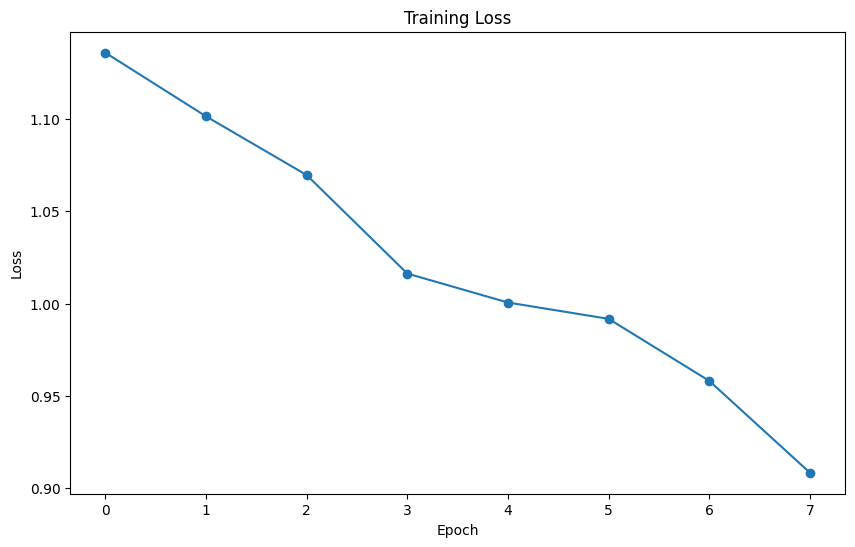

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses,marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [13]:
torch.save(model.state_dict(), "galaxy_model.pth")
print('saved')

saved


# **Reflection**


1.  mostly weights present in the first linear(8192,128) of the head and the two conv layers together r only  around 5k.
And in the week2 MLP the cnn's first layer is cheap convolution that sees the whole image.
2.   It's starts arount ln(num_classes) and then starts fall down .If it's flat curve from start it means u miss zero_grad.
And a nan means the LR is too high or inputs are not normalised.

3. Part 2 checks for real generalization, not just memorization-- it evaluates on validation/test data, plots train-vs-val loss curves to catch overfitting, and uses a confusion matrix to see which galaxy types the model confuses.

